# Modelos PyTorch — Classificação de Texto AI vs Human

Este notebook permite treinar e avaliar os modelos PyTorch implementados em `models/pytorch_models/`.

**Modelos disponíveis:**
- **Baseline** — Regressão Logística (TF-IDF)
- **DNN** — Deep Feedforward Network (TF-IDF)
- **LSTM** — Bidirectional LSTM com Embeddings
- **GRU** — Bidirectional GRU com Embeddings

**Classes:** Anthropic | Google | Human | Meta | OpenAI

## 0. Setup — Imports e Configuração

In [1]:
import sys
sys.path.append('../models/pytorch_models')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from dataset import TfidfDataset, SequenceDataset, clean_text, build_vocab
from models import BaselineClassifier, DNNClassifier, LSTMClassifier, GRUClassifier
from train import train, evaluate, predict, DEVICE

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

[pytorch_models] Using device: cpu
PyTorch version: 2.10.0
Device: cpu


In [2]:
# Hiperparâmetros 

CLASSES       = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
N_CLASSES     = len(CLASSES)

TFIDF_WORDS   = 2000     # tamanho do vocabulário TF-IDF
MAX_LEN       = 150      # comprimento máximo de sequência (RNN/LSTM/GRU)
MAX_VOCAB     = 10000    # tamanho do vocabulário para embeddings
EMBED_DIM     = 128      # dimensão dos embeddings
HIDDEN_DIM    = 128      # dimensão do estado oculto das RNNs

BATCH_SIZE    = 64
EPOCHS        = 100
LR            = 0.001
PATIENCE      = 10       # early stopping

TEST_SIZE     = 0.2
VAL_SIZE      = 0.1
RANDOM_STATE  = 42

print("Configuração carregada!")

Configuração carregada!


## 1. Carregar e Preparar os Dados

Total de exemplos: 4599

Distribuição por classe:


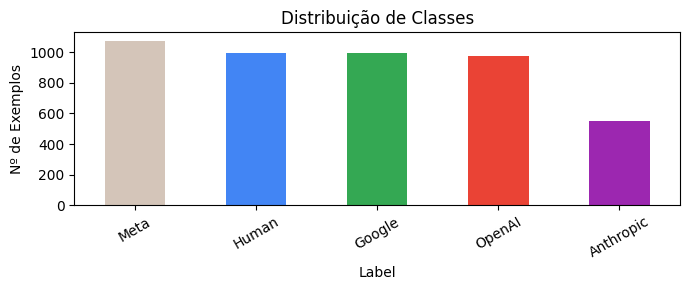

In [3]:
# Carregar dataset
df = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])

label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

texts  = df['Text'].tolist()
labels = [label2idx[l] for l in df['Label']]

print(f"Total de exemplos: {len(texts)}")
print("\nDistribuição por classe:")
df['Label'].value_counts().plot(kind='bar', color=['#D4C5B9', '#4285F4', '#34A853', '#EA4335', '#9C27B0'],
                                 figsize=(7, 3), title='Distribuição de Classes')
plt.ylabel('Nº de Exemplos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [4]:
# Split treino / validação / teste
X_tr, X_te, y_tr, y_te = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE, stratify=y_tr)

print(f"Treino:    {len(X_tr)} exemplos")
print(f"Validação: {len(X_val)} exemplos")
print(f"Teste:     {len(X_te)} exemplos")

Treino:    3219 exemplos
Validação: 460 exemplos
Teste:     920 exemplos


In [5]:
# Datasets TF-IDF (para Baseline e DNN) 
train_ds_tfidf = TfidfDataset(X_tr,  y_tr,  max_words=TFIDF_WORDS, train=True)
val_ds_tfidf   = TfidfDataset(X_val, y_val, vectorizer=train_ds_tfidf.vectorizer, train=False)
test_ds_tfidf  = TfidfDataset(X_te,  y_te,  vectorizer=train_ds_tfidf.vectorizer, train=False)

train_loader_tfidf = DataLoader(train_ds_tfidf, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tfidf   = DataLoader(val_ds_tfidf,   batch_size=BATCH_SIZE)
test_loader_tfidf  = DataLoader(test_ds_tfidf,  batch_size=BATCH_SIZE)

# Datasets de Sequências (para LSTM / GRU) 
clean_tr  = [clean_text(t) for t in X_tr]
word_index = build_vocab(clean_tr, max_words=MAX_VOCAB)
vocab_size = len(word_index) + 2

train_ds_seq = SequenceDataset(X_tr,  y_tr,  word_index, max_len=MAX_LEN)
val_ds_seq   = SequenceDataset(X_val, y_val, word_index, max_len=MAX_LEN)
test_ds_seq  = SequenceDataset(X_te,  y_te,  word_index, max_len=MAX_LEN)

train_loader_seq = DataLoader(train_ds_seq, batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq   = DataLoader(val_ds_seq,   batch_size=BATCH_SIZE)
test_loader_seq  = DataLoader(test_ds_seq,  batch_size=BATCH_SIZE)

print(f"Vocabulário (Embeddings): {vocab_size} palavras")

Vocabulário (Embeddings): 10002 palavras


## Funções de Visualização

In [6]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Treino',    color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Validação', color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Treino',    color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Validação', color='tomato')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion(model, loader, title='Matriz de Confusão'):
    preds = predict(model, loader).numpy()
    true  = [int(y) for _, y in loader.dataset]
    cm = confusion_matrix(true, preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title, fontweight='bold')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.tight_layout()
    plt.show()

    print(classification_report(true, preds, target_names=CLASSES))


---
## 2. Baseline — Regressão Logística (TF-IDF)

In [7]:
baseline = BaselineClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES)
criterion = nn.CrossEntropyLoss()

print("A treinar a Baseline (Regressão Logística + TF-IDF)...")
history_base = train(baseline, train_loader_tfidf, val_loader_tfidf, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar a Baseline (Regressão Logística + TF-IDF)...
Epoch 1/100 | train_loss: 1.5559 | train_acc: 0.5961 | val_loss: 1.5648 | val_acc: 0.5109
Epoch 2/100 | train_loss: 1.5060 | train_acc: 0.7313 | val_loss: 1.5240 | val_acc: 0.6196
Epoch 3/100 | train_loss: 1.4603 | train_acc: 0.7487 | val_loss: 1.4872 | val_acc: 0.6391
Epoch 4/100 | train_loss: 1.4173 | train_acc: 0.7909 | val_loss: 1.4526 | val_acc: 0.6826
Epoch 5/100 | train_loss: 1.3776 | train_acc: 0.8211 | val_loss: 1.4206 | val_acc: 0.7043
Epoch 6/100 | train_loss: 1.3382 | train_acc: 0.8248 | val_loss: 1.3905 | val_acc: 0.7087
Epoch 7/100 | train_loss: 1.3012 | train_acc: 0.8341 | val_loss: 1.3613 | val_acc: 0.7239
Epoch 8/100 | train_loss: 1.2662 | train_acc: 0.8369 | val_loss: 1.3339 | val_acc: 0.7261
Epoch 9/100 | train_loss: 1.2328 | train_acc: 0.8350 | val_loss: 1.3076 | val_acc: 0.7370
Epoch 10/100 | train_loss: 1.1990 | train_acc: 0.8397 | val_loss: 1.2819 | val_acc: 0.7391
Epoch 11/100 | train_loss: 1.1685 | train_ac

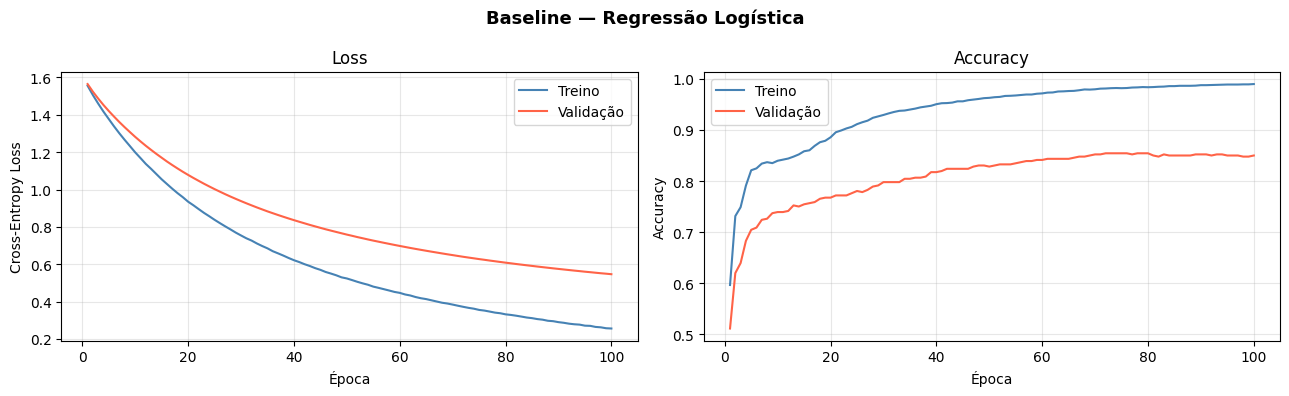


Accuracy no Teste (Baseline): 85.43%


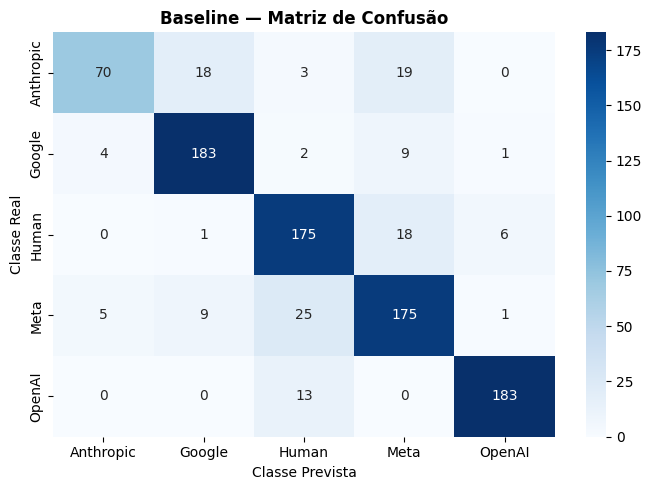

              precision    recall  f1-score   support

   Anthropic       0.89      0.64      0.74       110
      Google       0.87      0.92      0.89       199
       Human       0.80      0.88      0.84       200
        Meta       0.79      0.81      0.80       215
      OpenAI       0.96      0.93      0.95       196

    accuracy                           0.85       920
   macro avg       0.86      0.84      0.84       920
weighted avg       0.86      0.85      0.85       920



In [8]:
plot_history(history_base, 'Baseline — Regressão Logística')
_, acc_base = evaluate(baseline, test_loader_tfidf)
print(f"\nAccuracy no Teste (Baseline): {acc_base*100:.2f}%")
plot_confusion(baseline, test_loader_tfidf, 'Baseline — Matriz de Confusão')

---
## 3. DNN — Deep Feedforward Network (TF-IDF)

In [9]:
dnn = DNNClassifier(
    input_dim=TFIDF_WORDS,
    n_classes=N_CLASSES,
    topology=[256, 128, 64],   # camadas ocultas
    dropout=0.3
)

print("A treinar DNN (TF-IDF)...")
history_dnn = train(dnn, train_loader_tfidf, val_loader_tfidf, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar DNN (TF-IDF)...
Epoch 1/100 | train_loss: 1.2244 | train_acc: 0.5092 | val_loss: 1.2300 | val_acc: 0.5000
Epoch 2/100 | train_loss: 0.5551 | train_acc: 0.7791 | val_loss: 0.6870 | val_acc: 0.6696
Epoch 3/100 | train_loss: 0.3321 | train_acc: 0.8627 | val_loss: 0.6050 | val_acc: 0.7370
Epoch 4/100 | train_loss: 0.2178 | train_acc: 0.9199 | val_loss: 0.5629 | val_acc: 0.7696
Epoch 5/100 | train_loss: 0.1472 | train_acc: 0.9534 | val_loss: 0.5739 | val_acc: 0.7457
Epoch 6/100 | train_loss: 0.0905 | train_acc: 0.9736 | val_loss: 0.5727 | val_acc: 0.7652
Epoch 7/100 | train_loss: 0.0474 | train_acc: 0.9885 | val_loss: 0.6312 | val_acc: 0.7783
Epoch 8/100 | train_loss: 0.0244 | train_acc: 0.9966 | val_loss: 0.6428 | val_acc: 0.7913
Epoch 9/100 | train_loss: 0.0111 | train_acc: 0.9991 | val_loss: 0.7262 | val_acc: 0.7783
Epoch 10/100 | train_loss: 0.0076 | train_acc: 0.9991 | val_loss: 0.7238 | val_acc: 0.8196
Epoch 11/100 | train_loss: 0.0045 | train_acc: 0.9994 | val_loss: 0.7643 

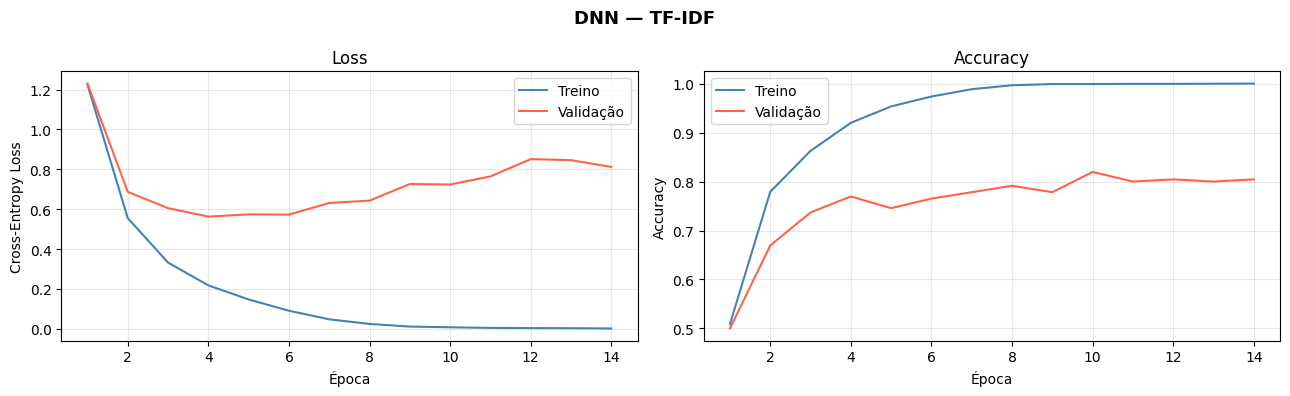


Accuracy no Teste (DNN): 83.15%


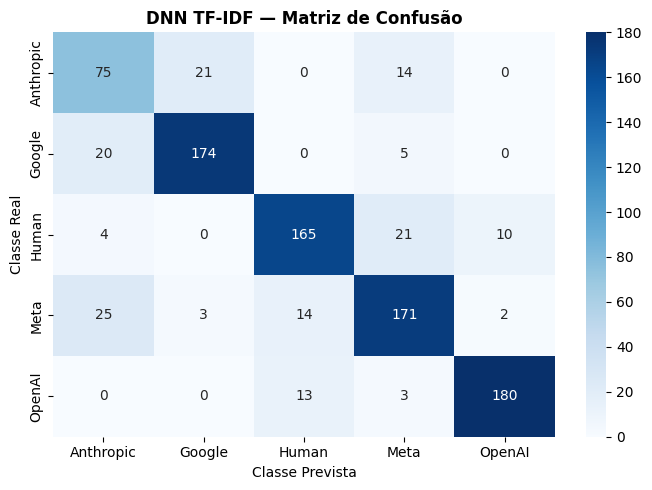

              precision    recall  f1-score   support

   Anthropic       0.60      0.68      0.64       110
      Google       0.88      0.87      0.88       199
       Human       0.86      0.82      0.84       200
        Meta       0.80      0.80      0.80       215
      OpenAI       0.94      0.92      0.93       196

    accuracy                           0.83       920
   macro avg       0.82      0.82      0.82       920
weighted avg       0.84      0.83      0.83       920



In [10]:
plot_history(history_dnn, 'DNN — TF-IDF')
_, acc_dnn = evaluate(dnn, test_loader_tfidf)
print(f"\nAccuracy no Teste (DNN): {acc_dnn*100:.2f}%")
plot_confusion(dnn, test_loader_tfidf, 'DNN TF-IDF — Matriz de Confusão')

---
## 4. BiLSTM — Embeddings

In [11]:
lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiLSTM (Embeddings)...")
history_lstm = train(lstm, train_loader_seq, val_loader_seq, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiLSTM (Embeddings)...
Epoch 1/100 | train_loss: 1.0519 | train_acc: 0.5853 | val_loss: 1.0937 | val_acc: 0.5500
Epoch 2/100 | train_loss: 0.7443 | train_acc: 0.6893 | val_loss: 0.8604 | val_acc: 0.6304
Epoch 3/100 | train_loss: 0.5163 | train_acc: 0.8065 | val_loss: 0.6852 | val_acc: 0.6978
Epoch 4/100 | train_loss: 0.3664 | train_acc: 0.8788 | val_loss: 0.6540 | val_acc: 0.7283
Epoch 5/100 | train_loss: 0.2787 | train_acc: 0.9012 | val_loss: 0.6610 | val_acc: 0.7565
Epoch 6/100 | train_loss: 0.4861 | train_acc: 0.8226 | val_loss: 0.9635 | val_acc: 0.6848
Epoch 7/100 | train_loss: 0.1508 | train_acc: 0.9540 | val_loss: 0.6948 | val_acc: 0.7587
Epoch 8/100 | train_loss: 0.1050 | train_acc: 0.9727 | val_loss: 0.7504 | val_acc: 0.7348
Epoch 9/100 | train_loss: 0.0642 | train_acc: 0.9851 | val_loss: 0.8511 | val_acc: 0.7391
Epoch 10/100 | train_loss: 0.0509 | train_acc: 0.9866 | val_loss: 0.8178 | val_acc: 0.7500
Epoch 11/100 | train_loss: 0.0390 | train_acc: 0.9891 | val_loss: 

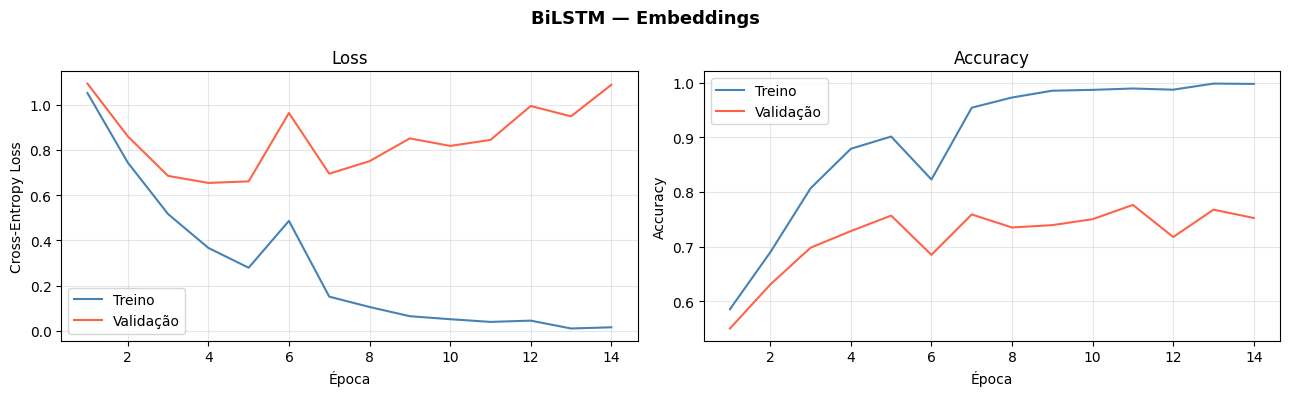


Accuracy no Teste (BiLSTM): 74.67%


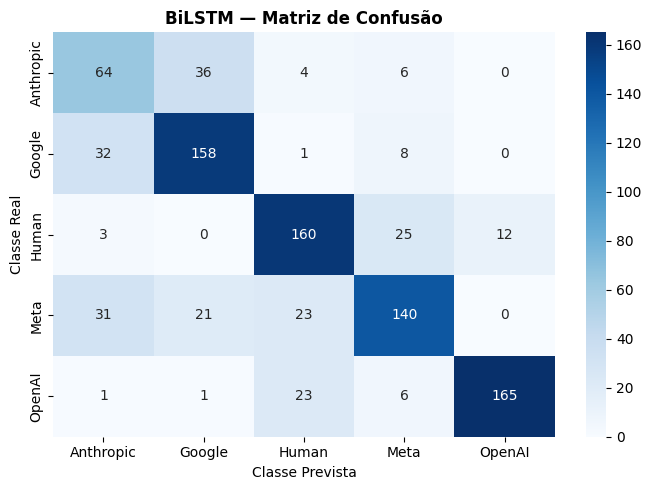

              precision    recall  f1-score   support

   Anthropic       0.49      0.58      0.53       110
      Google       0.73      0.79      0.76       199
       Human       0.76      0.80      0.78       200
        Meta       0.76      0.65      0.70       215
      OpenAI       0.93      0.84      0.88       196

    accuracy                           0.75       920
   macro avg       0.73      0.73      0.73       920
weighted avg       0.76      0.75      0.75       920



In [12]:
plot_history(history_lstm, 'BiLSTM — Embeddings')
_, acc_lstm = evaluate(lstm, test_loader_seq)
print(f"\nAccuracy no Teste (BiLSTM): {acc_lstm*100:.2f}%")
plot_confusion(lstm, test_loader_seq, 'BiLSTM — Matriz de Confusão')

---
## 5. BiGRU — Embeddings

In [13]:
gru = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiGRU (Embeddings)...")
history_gru = train(gru, train_loader_seq, val_loader_seq, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiGRU (Embeddings)...
Epoch 1/100 | train_loss: 1.0122 | train_acc: 0.6123 | val_loss: 1.0723 | val_acc: 0.5826
Epoch 2/100 | train_loss: 0.6467 | train_acc: 0.7530 | val_loss: 0.8046 | val_acc: 0.6652
Epoch 3/100 | train_loss: 0.5704 | train_acc: 0.7729 | val_loss: 0.9071 | val_acc: 0.6435
Epoch 4/100 | train_loss: 0.3971 | train_acc: 0.8406 | val_loss: 0.8395 | val_acc: 0.6674
Epoch 5/100 | train_loss: 0.1704 | train_acc: 0.9522 | val_loss: 0.7185 | val_acc: 0.7522
Epoch 6/100 | train_loss: 0.1270 | train_acc: 0.9609 | val_loss: 0.8764 | val_acc: 0.7348
Epoch 7/100 | train_loss: 0.0474 | train_acc: 0.9897 | val_loss: 0.8494 | val_acc: 0.7522
Epoch 8/100 | train_loss: 0.0888 | train_acc: 0.9727 | val_loss: 0.9546 | val_acc: 0.7391
Epoch 9/100 | train_loss: 0.0665 | train_acc: 0.9786 | val_loss: 0.8824 | val_acc: 0.7435
Epoch 10/100 | train_loss: 0.0136 | train_acc: 0.9988 | val_loss: 0.9177 | val_acc: 0.7652
Epoch 11/100 | train_loss: 0.0076 | train_acc: 0.9994 | val_loss: 0

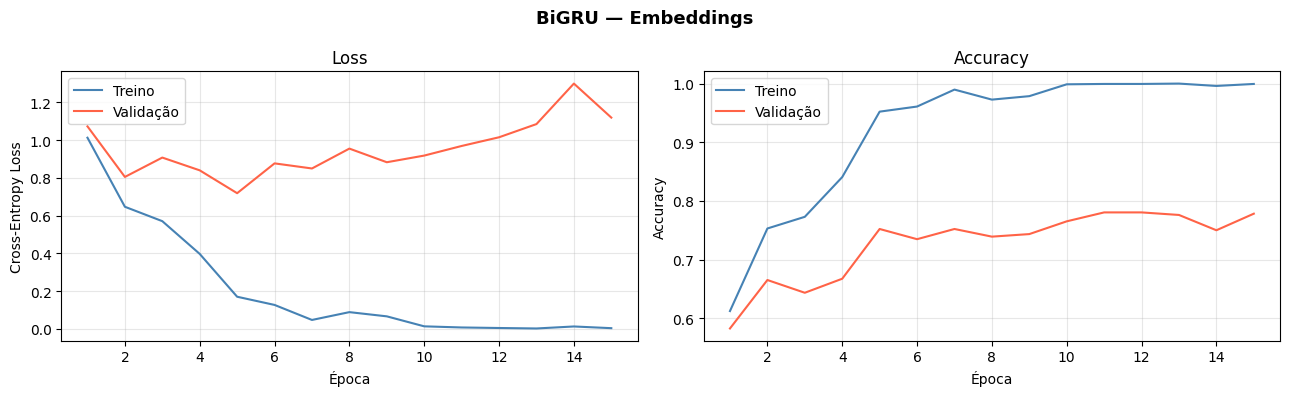


Accuracy no Teste (BiGRU): 78.04%


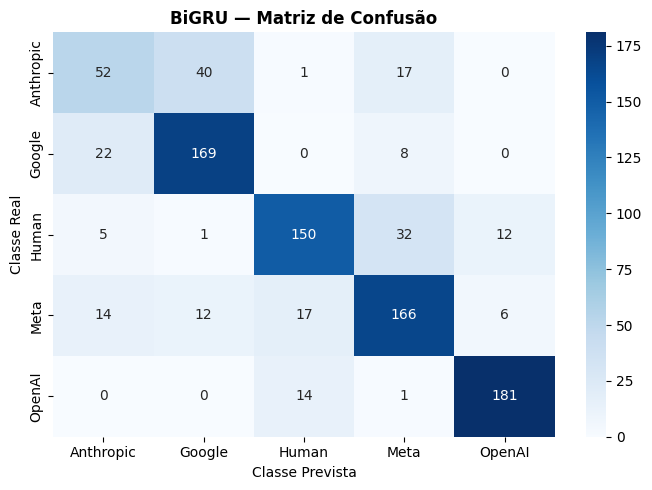

              precision    recall  f1-score   support

   Anthropic       0.56      0.47      0.51       110
      Google       0.76      0.85      0.80       199
       Human       0.82      0.75      0.79       200
        Meta       0.74      0.77      0.76       215
      OpenAI       0.91      0.92      0.92       196

    accuracy                           0.78       920
   macro avg       0.76      0.75      0.75       920
weighted avg       0.78      0.78      0.78       920



In [14]:
plot_history(history_gru, 'BiGRU — Embeddings')
_, acc_gru = evaluate(gru, test_loader_seq)
print(f"\nAccuracy no Teste (BiGRU): {acc_gru*100:.2f}%")
plot_confusion(gru, test_loader_seq, 'BiGRU — Matriz de Confusão')

---
## 6. Comparação Final dos Modelos


 COMPARAÇÃO DE MODELOS — Accuracy no Teste
  Baseline (LogReg)      85.43%  ██████████████████████████████████
  DNN (TF-IDF)           83.15%  █████████████████████████████████
  BiGRU                  78.04%  ███████████████████████████████
  BiLSTM                 74.67%  █████████████████████████████


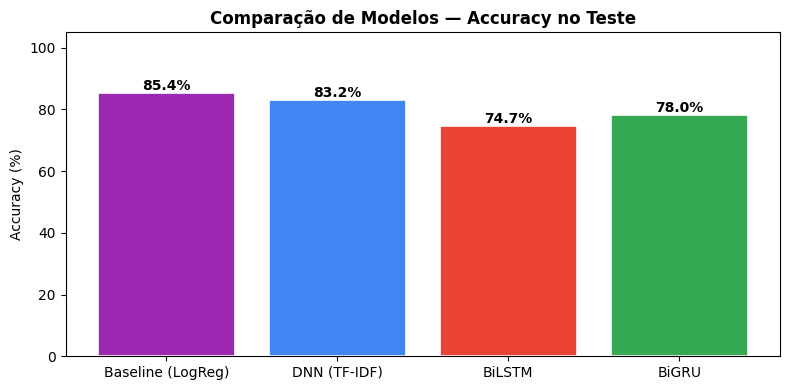

In [15]:
resultados = {
    'Baseline (LogReg)': acc_base,
    'DNN (TF-IDF)':      acc_dnn,
    'BiLSTM':            acc_lstm,
    'BiGRU':             acc_gru,
}

print("\n" + "="*45)
print(" COMPARAÇÃO DE MODELOS — Accuracy no Teste")
print("="*45)
for nome, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"  {nome:<22} {acc*100:5.2f}%  {bar}")
print("="*45)

# Gráfico de barras
plt.figure(figsize=(8, 4))
nomes = list(resultados.keys())
accs  = [v * 100 for v in resultados.values()]
cores = ['#9C27B0', '#4285F4', '#EA4335', '#34A853']
bars  = plt.bar(nomes, accs, color=cores, edgecolor='white', linewidth=1.2)
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Comparação de Modelos — Accuracy no Teste', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Guardar os Modelos

In [16]:
import os
save_dir = '../models/pytorch_models/saved_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(baseline.state_dict(), f'{save_dir}/baseline.pt')
torch.save(dnn.state_dict(),      f'{save_dir}/dnn_tfidf.pt')
torch.save(lstm.state_dict(),     f'{save_dir}/bilstm.pt')
torch.save(gru.state_dict(),      f'{save_dir}/bigru.pt')

print("Modelos guardados em:", save_dir)

Modelos guardados em: ../models/pytorch_models/saved_models


---
## 8. Carregar e Usar um Modelo Guardado

In [17]:
# Exemplo: carregar o DNN e classifcar um texto novo
model_loaded = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_loaded.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', weights_only=True))
model_loaded.eval()

def classificar_texto(texto: str) -> str:
    x = train_ds_tfidf.vectorizer.transform([texto]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = model_loaded(x_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()
    pred_idx = probs.argmax().item()
    print(f"Classe prevista: {CLASSES[pred_idx]}")
    print("Probabilidades:")
    for cls, p in zip(CLASSES, probs.tolist()):
        bar = '█' * int(p * 30)
        print(f"  {cls:<10} {p*100:5.1f}%  {bar}")
    return CLASSES[pred_idx]

# Testar com um texto
texto_teste = "The carbon cycle is a biogeochemical cycle where carbon is exchanged between the Earth's biosphere, atmosphere, and oceans."
classificar_texto(texto_teste)

Classe prevista: Human
Probabilidades:
  Anthropic    0.0%  
  Google       0.0%  
  Human       98.0%  █████████████████████████████
  Meta         0.1%  
  OpenAI       1.9%  


'Human'

---
## 9. Gerar Ficheiro de Submissão B (PyTorch)

Este passo lê o ficheiro `subm1.csv`, que contém apenas os textos de teste sem labels, carrega um dos modelos PyTorch treinados (neste caso, o **DNN**) e prevê a classe para cada texto. O resultado é depois exportado para `Subm1/subm1-g3-MIA-B.csv`.

In [19]:
import os
import pandas as pd
import torch

# 1. Ler o ficheiro de teste
subm_path = '../subm1.csv'
df_subm = pd.read_csv(subm_path, sep=';')

# 2. Certificar que a classe 'Mistral' foi removida das features de teste
# Transformar os textos usando o vectorizer TF-IDF já ajustado (train_ds_tfidf)
X_subm_tfidf = train_ds_tfidf.vectorizer.transform(df_subm['Text']).toarray()

# 3. Carregar o modelo guardado (DNN é o mais robusto do TF-IDF em Accuracy)
model_subm = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_subm.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', map_location=torch.device('cpu'), weights_only=True))
model_subm.eval()

# 4. Fazer predições
X_subm_tensor = torch.tensor(X_subm_tfidf, dtype=torch.float32)
with torch.no_grad():
    logits_subm = model_subm(X_subm_tensor)
    probs_subm = torch.softmax(logits_subm, dim=1)
    preds_idx = probs_subm.argmax(dim=1).numpy()

# 5. Mapear os indíces para as labels correspondentes
predicted_labels = [idx2label[idx] for idx in preds_idx]

# 6. Criar o DataFrame final
df_final_b = pd.DataFrame({
    'ID': df_subm['ID'],
    'Text': df_subm['Text'],
    'Label': predicted_labels
})

# 7. Guardar no diretório Subm1
output_dir = '../Subm1'
os.makedirs(output_dir, exist_ok=True)
output_filename = os.path.join(output_dir, 'subm1-g3-MIA-B.csv')

df_final_b.to_csv(output_filename, sep=';', index=False)

print(f"Ficheiro de submissão criado com sucesso: {output_filename}")
print(df_final_b.head())
print(df_final_b['Label'].value_counts())


Ficheiro de submissão criado com sucesso: ../Subm1/subm1-g3-MIA-B.csv
     ID                                               Text   Label
0  D2-1  A covalent bond is a chemical bond that involv...   Human
1  D2-2  A covalent bond forms when two atoms share one...   Human
2  D2-3  A covalent bond is a type of chemical bond whe...    Meta
3  D2-4  A covalent bond is a chemical bond that involv...  OpenAI
4  D2-5  Driven by exciting developments in the field o...  OpenAI
Label
Human        73
Meta         41
OpenAI       26
Anthropic     7
Google        3
Name: count, dtype: int64
